# Derivatives (Option) Pricing
### FINM3422 - Assessment 3 | Risk & Derivatives Platform

---

__Purpose:__ This notebook prices European and American options across a portfolio of five ASX-listed equities using the Black-Scholes closed-form model and the Cox-Ross-Rubinstein (CRR) binomial tree. Pricing is validated via Monte Carlo simulation and binomial convergence tests, and closed-form Greeks are computed and interpreted for each stock.

__Data Sources:__ RBA F17 (yield curve), Yahoo Finance via yfinance (equity data)

---

## 1.0 Background Information
---
## 1. Background

### 1.1 European Options — Black-Scholes with Merton Dividend Extension

A European option can only be exercised at maturity $T$. Under the Merton (1973) extension to Black-Scholes, the closed-form prices for a stock paying a continuous dividend yield $q$ are:

$$C = S_0 e^{-qT} N(d_1) - K e^{-rT} N(d_2)$$
$$P = K e^{-rT} N(-d_2) - S_0 e^{-qT} N(-d_1)$$

where:
$$d_1 = \frac{\ln(S_0/K) + (r - q + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

Setting $q = 0$ recovers the standard Black-Scholes formula. The risk-free rate $r$ is sourced from the RBA F17 yield curve at the option's maturity — ensuring maturity-matched discounting.

Dividend yields are sourced from current ASX data for each stock.

### 1.2 American Options — CRR Binomial Tree

An American option can be exercised at **any point before expiry**. We use the Cox-Ross-Rubinstein (CRR) binomial tree:

$$u = e^{\sigma\sqrt{\Delta t}}, \qquad d = \frac{1}{u}, \qquad p = \frac{e^{(r-q)\Delta t} - d}{u - d}$$

At each node the holder takes the maximum of early exercise and continuation:

$$V = \max\left(\text{Intrinsic},\ e^{-r\Delta t}\left[p V_u + (1-p) V_d\right]\right)$$

We use $N = 500$ steps. The tree is validated by confirming convergence to Black-Scholes for European options.

### 1.3 Monte Carlo Pricing

As an independent cross-check, European options are also priced via Monte Carlo simulation using Geometric Brownian Motion with antithetic variates:

$$S_T = S_0 \exp\left[(r - q - \tfrac{1}{2}\sigma^2)T + \sigma\sqrt{T}\, Z\right]$$

For every draw $Z$, its mirror $-Z$ is also simulated. This reduces variance and improves accuracy with the same number of paths.

### 1.4 Option Greeks

| Greek | Measures | Call | Put |
|---|---|---|---|
| Delta ($\Delta$) | Sensitivity to $S$ | 0 to 1 | -1 to 0 |
| Gamma ($\Gamma$) | Rate of change of delta | Always positive | Always positive |
| Vega ($\mathcal{V}$) | Sensitivity to $\sigma$ per 1% | Always positive | Always positive |
| Theta ($\Theta$) | Daily time erosion | Typically negative | Can be positive |
| Rho ($\rho$) | Sensitivity to $r$ per 1% | Positive | Negative |

## 2.0 Environment & Imports

In [1]:
# Import the necessary packages and libraries.
import sys, os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from IPython.display import HTML

# Add the project root to Python's path so src/ modules can be imported across all machines.
sys.path.append(os.path.abspath('..'))

from src.data_loader_yieldcurve import load_yield_curve_data, get_latest_yields
from src.yield_curve import YieldCurve
from src.derivative import EuropeanCall, EuropeanPut, AmericanCall, AmericanPut, BinomialEuropeanCall, BinomialEuropeanPut

# For consistency, display all float values to 4 decimal places.
pd.set_option("display.float_format", "{:.4f}".format)

# Print versions for loaded packages and libraries.
print()
try:
    print(f"sys       : Version {sys.version}")
    print(f"numpy     : Version {np.__version__}")
    print(f"pandas    : Version {pd.__version__}")
    print(f"matplotlib: Version {plt.matplotlib.__version__}")
    print(f"seaborn   : Version {sns.__version__}")
except NameError:
    print("One or more libraries failed to load — check errors above.")



sys       : Version 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]
numpy     : Version 2.4.4
pandas    : Version 3.0.3
matplotlib: Version 3.10.9
seaborn   : Version 0.13.2


## 3.0 Load Equity Data

Two years of daily closing prices for each ASX stock was downloaded via yfinance (API).

- **Spot Price (S0):** Most recent closing price
- **Annualised Volatility (σ):** Computed from daily log returns scaled by $\sqrt{252}$

Dividend yields are sourced from current ASX market data.

In [2]:
# Define the five ASX stocks with their dividend yields sourced from current market data.
stocks = {
    "CBA" : {"ticker": "CBA.AX", "sector": "Banking",           "div_yield": 0.029},
    "BHP" : {"ticker": "BHP.AX", "sector": "Materials",          "div_yield": 0.035},
    "CSL" : {"ticker": "CSL.AX", "sector": "Healthcare",         "div_yield": 0.029},
}

# Download 2 years of historical prices and compute spot price and volatility for each stock.
for name, info in stocks.items():
    data = yf.download(info["ticker"], period="2y", auto_adjust=True, progress=False)
    # Handle MultiIndex columns returned by some yfinance versions.
    if isinstance(data.columns, pd.MultiIndex):
        close_series = data[("Close", info["ticker"])]
    else:
        close_series = data["Close"]
    info["S0"]    = float(close_series.iloc[-1])
    log_returns   = np.log(close_series / close_series.shift(1)).dropna()
    info["sigma"] = float(log_returns.std() * np.sqrt(252))

# Display equity summary table.
rows = []
for name, d in stocks.items():
    rows.append({
        "Stock"               : name,
        "Sector"              : d["sector"],
        "Spot Price ($)"      : round(d["S0"], 2),
        "Volatility (% p.a.)" : round(d["sigma"] * 100, 2),
        "Dividend Yield (%)"  : round(d["div_yield"] * 100, 2),
    })

eq_table       = pd.DataFrame(rows)
eq_table.index = [""] * len(eq_table)
print("Equity data (2-year historical volatility, current dividend yields):")
display(eq_table)

Equity data (2-year historical volatility, current dividend yields):


,Stock,Sector,Spot Price ($),Volatility (% p.a.),Dividend Yield (%)
,CBA,Banking,162.2800,23.3400,2.9000
,BHP,Materials,61.7100,24.9700,3.5000
,CSL,Healthcare,95.4600,30.9500,2.9000


## 4.0 Construct Yield Curve

The yield curve is constructed from the latest RBA F17 zero-coupon interest rate data. This provides the risk-free rate $r$ at each option maturity, ensuring maturity-matched discounting rather than a flat assumed rate.

In [3]:
# Construct the yield curve from the latest RBA F17 data.
# This is the single source of truth for r throughout the notebook.
yield_curve = YieldCurve.from_rba(interpolation="linear", compounding="continuous")

# Confirm rates at key option maturities.
print("Risk-free rates at option maturities (from RBA F17):")
for T, label in [(0.25, "3 months"), (0.5, "6 months"), (1.0, "1 year")]:
    r = yield_curve.get_zero_rate(T)
    d = yield_curve.get_discount_factor(T)
    print(f"  {label:<12} | r = {r*100:.4f}% | D(T) = {d:.6f}")


[data_loader] Loaded from cache: c:\Users\indig\OneDrive\Documents\FINM3422-Financial Modelling\A3-FINM3422\FINM3422_A3_T7_G1_DP\src\..\data\F17_DATA_CLEAN.csv
 [YieldCurve] Built from RBA F17 data as of 30-04-2026.
 Maturities: 41 points (0yr to 10yr in 0.25yr increments.)
 Compounding: continuous
 Interpolation: linear
Risk-free rates at option maturities (from RBA F17):
  3 months     | r = 4.3000% | D(T) = 0.989308
  6 months     | r = 4.4600% | D(T) = 0.977947
  1 year       | r = 4.6300% | D(T) = 0.954755


## 5.0 Option Pricing - All Stocks & Option Types

We price European and American calls and puts for each stock at three maturities (3m, 6m, 1yr) using an **at-the-money strike** ($K = S_0$). Dividend yields are included via the Merton extension.

In [4]:
maturities = {"3m": 0.25, "6m": 0.50, "1yr": 1.0}

rows = []
for stock, d in stocks.items():
    S0, sigma, q = d["S0"], d["sigma"], d["div_yield"]
    K = S0  # at-the-money strike

    for mat_label, T in maturities.items():
        eu_call = EuropeanCall(S0, K, T, sigma, yield_curve, dividend_yield=q)
        eu_put  = EuropeanPut(S0, K, T, sigma, yield_curve, dividend_yield=q)
        am_call = AmericanCall(S0, K, T, sigma, yield_curve, dividend_yield=q)
        am_put  = AmericanPut(S0, K, T, sigma, yield_curve, dividend_yield=q)

        rows.append({
            "Stock"       : stock,
            "Maturity"    : mat_label,
            "Spot ($)"    : round(S0, 2),
            "σ (% p.a.)"  : round(sigma * 100, 2),
            "q (%)"       : round(q * 100, 2),
            "EU Call ($)" : round(eu_call.price(), 4),
            "EU Put ($)"  : round(eu_put.price(), 4),
            "AM Call ($)" : round(am_call.price(), 4),
            "AM Put ($)"  : round(am_put.price(), 4),
        })

pricing_table = pd.DataFrame(rows)
pricing_table.index = [""] * len(pricing_table)
print("Option prices — ATM strike, all maturities:")
display(pricing_table)

Option prices — ATM strike, all maturities:


,Stock,Maturity,Spot ($),σ (% p.a.),q (%),EU Call ($),EU Put ($),AM Call ($),AM Put ($)
,CBA,3m,162.2800,23.3400,2.9000,7.7694,7.2065,7.7685,7.2544
,CBA,6m,162.2800,23.3400,2.9000,11.1130,9.8702,11.1117,10.0001
,CBA,1yr,162.2800,23.3400,2.9000,15.9138,13.2100,15.9143,13.5641
,BHP,3m,61.7100,24.9700,3.5000,3.1032,2.9809,3.1031,2.9932
,BHP,6m,61.7100,24.9700,3.5000,4.4021,4.1117,4.4035,4.1485
,BHP,1yr,61.7100,24.9700,3.5000,6.2276,5.5581,6.2374,5.6666
,CSL,3m,95.4600,30.9500,2.9000,6.0023,5.6712,6.0016,5.7006
,CSL,6m,95.4600,30.9500,2.9000,8.5377,7.8067,8.5373,7.8881
,CSL,1yr,95.4600,30.9500,2.9000,12.1202,10.5298,12.1261,10.7572


__Interpretation__

The table prices at-the-money options for each stock at 3-month, 6-month, and 1-year maturities. Prices generally rise with maturity because the option has more time for the underlying share price to move favourably. Higher-volatility stocks also have larger option values, since both calls and puts benefit from a wider distribution of possible future prices.

The American put is at least as valuable as the European put because the holder can exercise early if that becomes optimal. The American call premium is usually small for these continuously dividend-adjusted examples, but it can appear when dividends make early exercise more attractive.


## 6.0 Monte Carlo Validation

We validate the Black-Scholes closed-form prices against Monte Carlo simulation using 100,000 paths with antithetic variates. Both methods should agree closely — any large difference would indicate a bug.

In [5]:
T = 1.0  # 1-year maturity for MC validation
rows = []

for stock, d in stocks.items():
    S0, sigma, q = d["S0"], d["sigma"], d["div_yield"]
    K = S0

    call = EuropeanCall(S0, K, T, sigma, yield_curve, dividend_yield=q)
    put  = EuropeanPut(S0, K, T, sigma, yield_curve, dividend_yield=q)

    call_result = call.mc_vs_bs(n_sims=100_000)
    put_result  = put.mc_vs_bs(n_sims=100_000)

    rows.append({
        "Stock"            : stock,
        "Call BS ($)"      : call_result["BS Price ($)"],
        "Call MC ($)"      : call_result["MC Price ($)"],
        "Call Diff ($)"    : call_result["Difference ($)"],
        "Put BS ($)"       : put_result["BS Price ($)"],
        "Put MC ($)"       : put_result["MC Price ($)"],
        "Put Diff ($)"     : put_result["Difference ($)"],
    })

mc_table = pd.DataFrame(rows)
mc_table.index = [""] * len(mc_table)
print("Monte Carlo vs Black-Scholes validation (ATM, 1yr, 100,000 paths):")
display(mc_table)

Monte Carlo vs Black-Scholes validation (ATM, 1yr, 100,000 paths):


,Stock,Call BS ($),Call MC ($),Call Diff ($),Put BS ($),Put MC ($),Put Diff ($)
,CBA,15.9138,15.9161,0.0023,13.2100,13.2109,0.0009
,BHP,6.2276,6.2288,0.0012,5.5581,5.5586,0.0006
,CSL,12.1202,12.1231,0.0028,10.5298,10.5311,0.0014


__Interpretation__

The Monte Carlo estimates should sit close to the Black-Scholes prices. Any remaining difference is simulation error from using a finite number of paths, not a structural pricing difference. The small call and put differences therefore provide a cross-check that the closed-form formula and the simulated risk-neutral payoff are implemented consistently.

Using 100,000 paths keeps the validation accurate enough for diagnosis while still being practical to rerun inside the notebook.


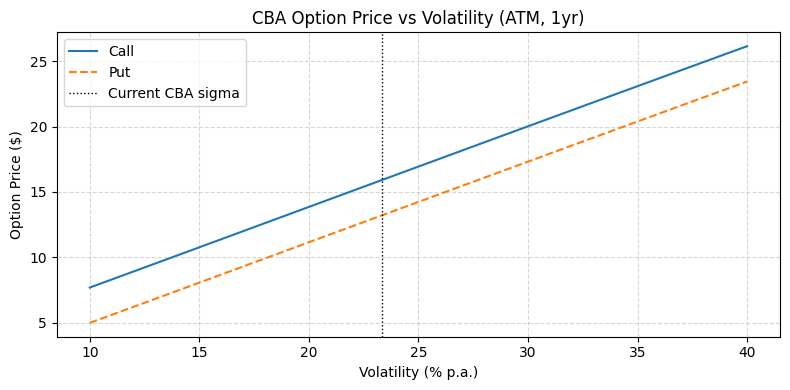

In [6]:
# Volatility sense check - both prices should increase with sigma.
stock = "CBA"
S0    = stocks[stock]["S0"]
sigma = stocks[stock]["sigma"]
q     = stocks[stock]["div_yield"]
K     = S0
T     = 1.0

vols        = np.linspace(0.1, 0.4, 10)
call_prices = [EuropeanCall(S0, K, T, v, yield_curve, dividend_yield=q).price() for v in vols]
put_prices  = [EuropeanPut(S0, K, T, v, yield_curve, dividend_yield=q).price()  for v in vols]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(vols * 100, call_prices, label="Call")
ax.plot(vols * 100, put_prices,  label="Put",  linestyle="--")
ax.axvline(sigma * 100, color="black", linestyle=":", linewidth=1, label=f"Current {stock} sigma")
ax.set_title(f"{stock} Option Price vs Volatility (ATM, 1yr)")
ax.set_xlabel("Volatility (% p.a.)")
ax.set_ylabel("Option Price ($)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## 7.0 Binomial Tree Convergence

We validate the CRR binomial tree by confirming it converges to the Black-Scholes price as the number of steps $N$ increases. Error should decay as $O(1/N)$.

In [7]:
# Use CBA as a representative stock for convergence testing
S0    = stocks["CBA"]["S0"]
sigma = stocks["CBA"]["sigma"]
q     = stocks["CBA"]["div_yield"]
K     = S0
T     = 1.0

# Black-Scholes reference prices
bs_call = EuropeanCall(S0, K, T, sigma, yield_curve, dividend_yield=q).price()
bs_put  = EuropeanPut(S0, K, T, sigma, yield_curve, dividend_yield=q).price()

# Binomial prices at increasing N
steps = [50, 100, 200, 500, 1000]
rows  = []
for N in steps:
    bin_call = BinomialEuropeanCall(S0, K, T, sigma, yield_curve, dividend_yield=q, N=N).price()
    bin_put  = BinomialEuropeanPut(S0, K, T, sigma, yield_curve, dividend_yield=q, N=N).price()
    rows.append({
        "N steps"         : N,
        "Bin Call ($)"    : round(bin_call, 6),
        "BS Call ($)"     : round(bs_call, 6),
        "Call Error ($)"  : round(abs(bin_call - bs_call), 6),
        "Bin Put ($)"     : round(bin_put, 6),
        "BS Put ($)"      : round(bs_put, 6),
        "Put Error ($)"   : round(abs(bin_put - bs_put), 6),
    })

conv_table = pd.DataFrame(rows)
conv_table.index = [""] * len(conv_table)
print(f"CBA binomial tree convergence to Black-Scholes (ATM, 1yr):")
display(conv_table)

CBA binomial tree convergence to Black-Scholes (ATM, 1yr):


,N steps,Bin Call ($),BS Call ($),Call Error ($),Bin Put ($),BS Put ($),Put Error ($)
,50,15.8412,15.9138,0.0726,13.1374,13.2100,0.0726
,100,15.8774,15.9138,0.0364,13.1737,13.2100,0.0364
,200,15.8956,15.9138,0.0182,13.1919,13.2100,0.0182
,500,15.9065,15.9138,0.0073,13.2028,13.2100,0.0073
,1000,15.9102,15.9138,0.0036,13.2064,13.2100,0.0036


## 8.0 Put-Call Parity Validation

Put-call parity with dividends states:
$$C - P = S_0 e^{-qT} - K e^{-rT}$$

We verify this holds for all five stocks at the 1-year maturity, confirming internal consistency of the Black-Scholes implementation.

In [8]:
T = 1.0
rows = []

for stock, d in stocks.items():
    S0, sigma, q = d["S0"], d["sigma"], d["div_yield"]
    K = S0
    r = yield_curve.get_zero_rate(T)

    call = EuropeanCall(S0, K, T, sigma, yield_curve, dividend_yield=q)
    put  = EuropeanPut(S0, K, T, sigma, yield_curve, dividend_yield=q)

    lhs  = call.price() - put.price()
    rhs  = S0 * np.exp(-q * T) - K * np.exp(-r * T)
    diff = abs(lhs - rhs)

    rows.append({
        "Stock"                : stock,
        "LHS (C - P)"          : round(lhs, 6),
        "RHS (Se^-qT - Ke^-rT)": round(rhs, 6),
        "Difference"           : round(diff, 8),
        "Parity holds"         : diff < 1e-6,
    })

parity_table = pd.DataFrame(rows)
parity_table.index = [""] * len(parity_table)
print("Put-call parity check — ATM, 1yr, with dividends:")
display(parity_table)

Put-call parity check — ATM, 1yr, with dividends:


,Stock,LHS (C - P),RHS (Se^-qT - Ke^-rT),Difference,Parity holds
,CBA,2.7037,2.7037,0.0000,True
,BHP,0.6695,0.6695,0.0000,True
,CSL,1.5905,1.5905,0.0000,True


__Interpretation__

Put-call parity holds when the dividend yield is included: `C - P = S0 e^{-qT} - K e^{-rT}`. The differences should be effectively zero up to rounding, which confirms that the call and put formulas use the same discounting, maturity, dividend yield, and strike assumptions.

This is an important internal consistency test because a parity failure would usually indicate a mismatched rate, an omitted dividend term, or an implementation error in one side of the pricing model.


## 9.0 Greeks Analysis

We compute all closed-form Greeks for each stock at the 1-year maturity using an ATM strike.

In [9]:
T = 1.0
rows = []

for stock, d in stocks.items():
    S0, sigma, q = d["S0"], d["sigma"], d["div_yield"]
    K = S0

    call = EuropeanCall(S0, K, T, sigma, yield_curve, dividend_yield=q)
    put  = EuropeanPut(S0, K, T, sigma, yield_curve, dividend_yield=q)

    for option, greeks in [("Call", call.all_greeks()), ("Put", put.all_greeks())]:
        rows.append({
            "Stock" : stock,
            "Type"  : option,
            "Delta" : round(greeks["delta"], 4),
            "Gamma" : round(greeks["gamma"], 6),
            "Vega"  : round(greeks["vega"],  4),
            "Theta" : round(greeks["theta"], 4),
            "Rho"   : round(greeks["rho"],   4),
        })

greeks_table = pd.DataFrame(rows)
greeks_table.index = [""] * len(greeks_table)
print("Greeks — ATM, 1yr, closed-form:")
display(greeks_table)

Greeks — ATM, 1yr, closed-form:


,Stock,Type,Delta,Gamma,Vega,Theta,Rho
,CBA,Call,0.5592,0.0100,0.6176,-0.0220,0.7484
,CBA,Put,-0.4122,0.0100,0.6176,-0.0149,-0.8010
,BHP,Call,0.5480,0.0246,0.2343,-0.0083,0.2759
,BHP,Put,-0.4176,0.0246,0.2343,-0.0065,-0.3133
,CSL,Call,0.5667,0.0128,0.3618,-0.0164,0.4198
,CSL,Put,-0.4047,0.0128,0.3618,-0.0122,-0.4916


__Interpretation__

The call deltas are positive and the put deltas are negative, matching the direction of each payoff. Gamma is positive for both calls and puts, meaning the option delta becomes more sensitive as the underlying moves near the strike. Vega is positive because higher volatility increases the value of optionality for both payoff types.

Theta is generally negative for long options because time decay reduces the remaining opportunity for the option to finish in-the-money. Rho is positive for calls and negative for puts: higher interest rates reduce the present value of the strike, helping calls and hurting puts.


### 9.1 Delta Sensitivity - Spot Price vs Delta

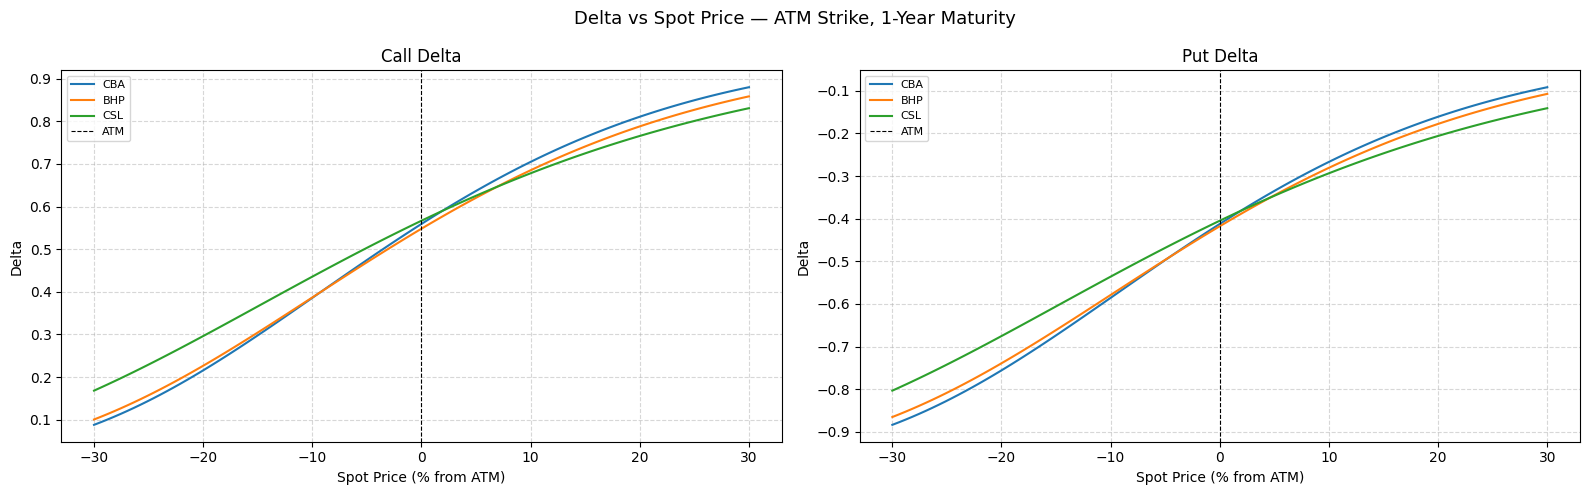

In [10]:
T   = 1.0
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Delta vs Spot Price — ATM Strike, 1-Year Maturity", fontsize=13)

for stock, d in stocks.items():
    S0, sigma, q = d["S0"], d["sigma"], d["div_yield"]
    K = S0

    # Range of spot prices: 70% to 130% of current spot
    S_range = np.linspace(S0 * 0.7, S0 * 1.3, 100)

    # Normalise x-axis to % of spot for comparability across stocks
    x             = (S_range / S0 - 1) * 100
    call_deltas   = [EuropeanCall(S, K, T, sigma, yield_curve, dividend_yield=q).delta() for S in S_range]
    put_deltas    = [EuropeanPut(S, K, T, sigma, yield_curve, dividend_yield=q).delta()  for S in S_range]

    axes[0].plot(x, call_deltas, label=stock)
    axes[1].plot(x, put_deltas,  label=stock)

for ax, title in zip(axes, ["Call Delta", "Put Delta"]):
    ax.axvline(0, color="black", linestyle="--", linewidth=0.8, label="ATM")
    ax.set_xlabel("Spot Price (% from ATM)")
    ax.set_ylabel("Delta")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

__Interpretation__

The delta curves show the expected transition around the at-the-money strike. Call delta rises toward 1 as the option moves deeper in-the-money, while put delta rises toward 0 from below as the put moves out-of-the-money. Around the strike, both curves are steepest, which is also where gamma risk is most concentrated.

Normalising the x-axis by percentage distance from the current spot makes the five stocks comparable despite their different share prices.


## 10.0 American vs European Price Comparison

We compare American and European prices to demonstrate the early exercise premium.

In [11]:
T = 1.0
rows = []

for stock, d in stocks.items():
    S0, sigma, q = d["S0"], d["sigma"], d["div_yield"]
    K = S0

    eu_c = EuropeanCall(S0, K, T, sigma, yield_curve, dividend_yield=q).price()
    eu_p = EuropeanPut(S0, K, T, sigma, yield_curve, dividend_yield=q).price()
    am_c = AmericanCall(S0, K, T, sigma, yield_curve, dividend_yield=q).price()
    am_p = AmericanPut(S0, K, T, sigma, yield_curve, dividend_yield=q).price()

    rows.append({
        "Stock"            : stock,
        "EU Call ($)"      : round(eu_c, 4),
        "AM Call ($)"      : round(am_c, 4),
        "Call Premium ($)" : round(am_c - eu_c, 6),
        "EU Put ($)"       : round(eu_p, 4),
        "AM Put ($)"       : round(am_p, 4),
        "Put Premium ($)"  : round(am_p - eu_p, 6),
    })

am_eu_table = pd.DataFrame(rows)
am_eu_table.index = [""] * len(am_eu_table)
print("American vs European early exercise premium (ATM, 1yr):")
display(am_eu_table)

American vs European early exercise premium (ATM, 1yr):


,Stock,EU Call ($),AM Call ($),Call Premium ($),EU Put ($),AM Put ($),Put Premium ($)
,CBA,15.9138,15.9143,0.0005,13.2100,13.5641,0.3541
,BHP,6.2276,6.2374,0.0098,5.5581,5.6666,0.1086
,CSL,12.1202,12.1261,0.0059,10.5298,10.7572,0.2275


__Interpretation__

The early-exercise premium is the difference between the American and European price. For puts, this premium should be non-negative because the American holder can choose to exercise early when immediate intrinsic value is preferable to waiting. For calls, the premium is often small unless dividend yield is high enough to make early exercise worthwhile.

These results support the modelling choice used later in the portfolio notebook: European contracts are suitable when early exercise is not relevant, while American contracts require the binomial tree because the exercise decision must be checked at each node.
